In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
os.makedirs('../outputs', exist_ok=True)

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import OneHotEncoder, StandardScaler
from sklearn.compose            import ColumnTransformer
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (accuracy_score, precision_score,
                                         recall_score, f1_score,
                                         roc_auc_score, roc_curve,
                                         confusion_matrix, classification_report)
from xgboost                    import XGBClassifier
from imblearn.over_sampling     import SMOTE
data = pd.read_csv('./new-cleaned_data.csv')
display(data.info(), data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5149 entries, 0 to 5148
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5149 non-null   object 
 1   age                5149 non-null   float64
 2   hypertension       5149 non-null   int64  
 3   heart_disease      5149 non-null   int64  
 4   ever_married       5149 non-null   object 
 5   work_type          5149 non-null   object 
 6   Residence_type     5149 non-null   object 
 7   avg_glucose_level  5149 non-null   float64
 8   bmi                5149 non-null   float64
 9   smoking_status     5149 non-null   object 
 10  stroke             5149 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 442.6+ KB


None

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.7,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.2,28.897009,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.9,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.2,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.1,24.000000,never smoked,1


In [22]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numerical_cols   = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

X = data.drop(columns=['stroke'])
y = data['stroke']

In [23]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('scaler', StandardScaler(),                                  numerical_cols)
    ], remainder='drop')

def fit_and_transform(preprocessor, X_tr, X_val=None, X_te=None):
    preprocessor.fit(X_tr)
    X_tr_proc  = preprocessor.transform(X_tr)
    X_val_proc = preprocessor.transform(X_val) if X_val is not None else None
    X_te_proc  = preprocessor.transform(X_te)  if X_te  is not None else None
    ohe_names  = (preprocessor.named_transformers_['onehot']
                  .get_feature_names_out(categorical_cols).tolist())
    feature_names = ohe_names + numerical_cols
    X_tr_proc     = pd.DataFrame(X_tr_proc,  columns=feature_names)
    if X_val_proc is not None:
        X_val_proc = pd.DataFrame(X_val_proc, columns=feature_names)
    if X_te_proc  is not None:
        X_te_proc  = pd.DataFrame(X_te_proc,  columns=feature_names)
    return X_tr_proc, X_val_proc, X_te_proc, feature_names

def find_youden_threshold(model, X_tr, y_tr):
    proba = model.predict_proba(X_tr)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_tr, proba)
    return round(float(thresholds[np.argmax(tpr - fpr)]), 4)

def train_models(X_tr, y_tr):
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    spw      = round(neg / pos, 2)
    print(f'  Class counts → No Stroke: {neg:,}  |  Stroke: {pos:,}  |  Ratio: {spw}')
    models = {
        'Logistic Regression': LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced_subsample',
            min_samples_leaf=2, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(
            n_estimators=300, scale_pos_weight=spw, max_depth=4,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, verbosity=0)
    }
    thresholds = {}
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        thresholds[name] = find_youden_threshold(model, X_tr, y_tr)
        print(f' {name} trained  (threshold={thresholds[name]})')
    return models, thresholds

def evaluate_model(name, model, X_ev, y_ev, threshold, split_label=''):
    y_proba = model.predict_proba(X_ev)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    acc  = accuracy_score(y_ev, y_pred)
    prec = precision_score(y_ev, y_pred, zero_division=0)
    rec  = recall_score(y_ev, y_pred, zero_division=0)
    f1   = f1_score(y_ev, y_pred, zero_division=0)
    auc  = roc_auc_score(y_ev, y_proba)
    cm   = confusion_matrix(y_ev, y_pred)
    tn, fp, fn, tp = cm.ravel()
    label = f'{name}' + (f' [{split_label}]' if split_label else '')
    return {'Model': name, 'Split': split_label, 'Threshold': threshold,
            'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1 Score': f1, 'ROC-AUC': auc,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            '_y_proba': y_proba, '_y_true': y_ev.values}

def plot_confusion_matrices(results, title, filename):
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
    if len(results) == 1: axes = [axes]
    for ax, res in zip(axes, results):
        cm = np.array([[res['TN'], res['FP']], [res['FN'], res['TP']]])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'])
        ax.set_title(f"{res['Model']}\n(thr={res['Threshold']})", fontsize=10, fontweight='bold')
        ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./outputs/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_curves(results, title, filename):
    fig, ax = plt.subplots(figsize=(8, 6))
    for res, color in zip(results, ['#3498db','#27ae60','#e74c3c']):
        fpr, tpr, _ = roc_curve(res['_y_true'], res['_y_proba'])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{res['Model']}  (AUC={res['ROC-AUC']:.4f})")
    ax.plot([0,1],[0,1],'k--',lw=1.2, label='Random (AUC=0.50)')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'./outputs/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

def print_distribution(y, label):
    counts = y.value_counts(); pct = y.value_counts(normalize=True) * 100

In [24]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print_distribution(y_train_80, 'Training (original)')

preprocessor_80s = build_preprocessor()
X_train_80_proc, _, X_test_80_proc, feature_names = fit_and_transform(
    preprocessor_80s, X_train_80, X_te=X_test_80)

smote = SMOTE(
    sampling_strategy='minority',
    k_neighbors=5,
    random_state=42
)

X_train_80_smote, y_train_80_smote = smote.fit_resample(
    X_train_80_proc, y_train_80)

y_train_80_smote = pd.Series(y_train_80_smote)

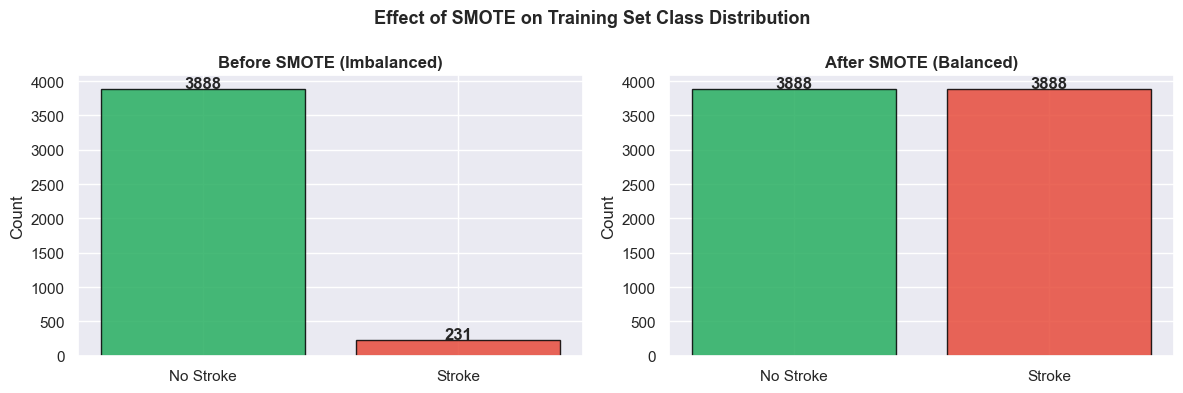

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts_before = y_train_80.value_counts()
axes[0].bar(['No Stroke', 'Stroke'], counts_before.values,
            color=['#27ae60','#e74c3c'], edgecolor='black', alpha=0.85)
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Before SMOTE (Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Count')

counts_after = y_train_80_smote.value_counts()
axes[1].bar(['No Stroke', 'Stroke'], counts_after.values,
            color=['#27ae60','#e74c3c'], edgecolor='black', alpha=0.85)
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[1].set_title('After SMOTE (Balanced)', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Effect of SMOTE on Training Set Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/04_smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
models_80s, thresholds_80s = train_models(X_train_80_smote, y_train_80_smote)

  Class counts → No Stroke: 3,888  |  Stroke: 3,888  |  Ratio: 1.0
 Logistic Regression trained  (threshold=0.4606)
 Random Forest trained  (threshold=0.4829)
 XGBoost trained  (threshold=0.5471)


In [27]:
results_80s = []
for name, model in models_80s.items():
    res = evaluate_model(name, model, X_test_80_proc, y_test_80,thresholds_80s[name], split_label='Test-SMOTE')
    results_80s.append(res)

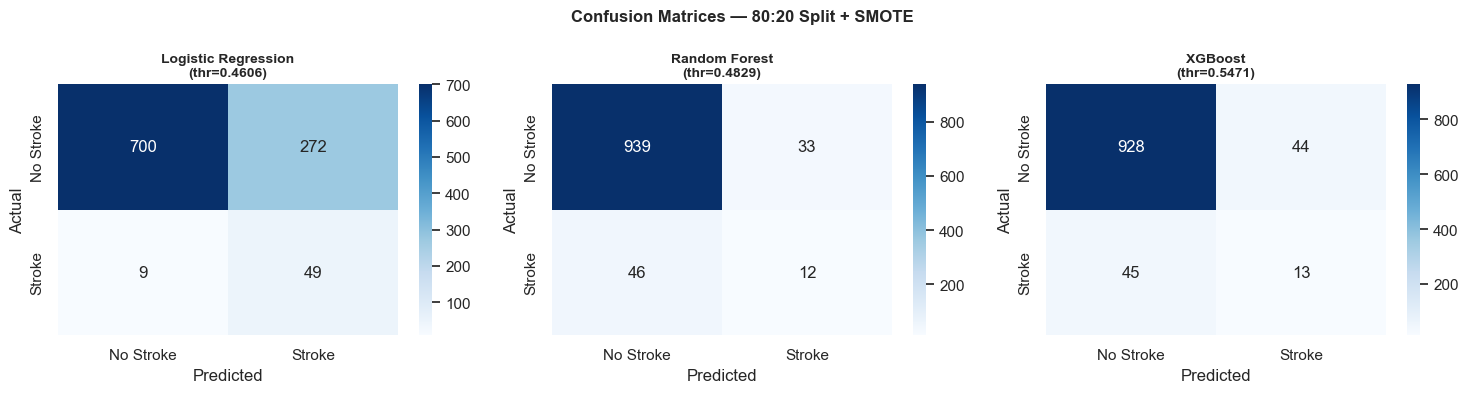

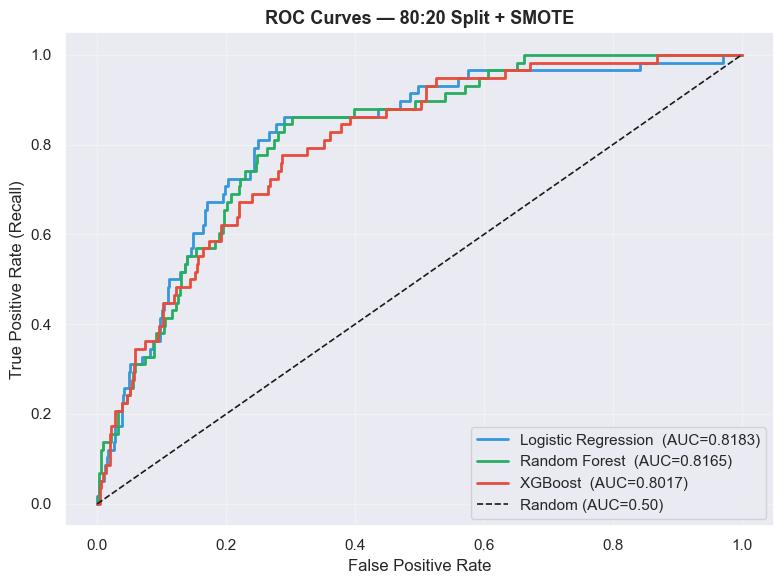

In [28]:
plot_confusion_matrices(results_80s,
    'Confusion Matrices — 80:20 Split + SMOTE',
    '04A_confusion_matrices_8020_smote.png')
plot_roc_curves(results_80s,
    'ROC Curves — 80:20 Split + SMOTE',
    '04A_roc_curves_8020_smote.png')

In [29]:
X_temp,    X_test_s,  y_temp,    y_test_s  = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)
X_train_s, X_val_s,   y_train_s, y_val_s   = train_test_split(
    X_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp)

print_distribution(y_train_s, 'Training (70%)')
print(); print_distribution(y_val_s, 'Validation (20%)')
print(); print_distribution(y_test_s, 'Test (10%)')

preprocessor_70s = build_preprocessor()
X_train_s_proc, X_val_s_proc, X_test_s_proc, _ = fit_and_transform(
    preprocessor_70s, X_train_s, X_val=X_val_s, X_te=X_test_s)

smote2 = SMOTE(sampling_strategy='minority', k_neighbors=5, random_state=42)
X_train_s_smote, y_train_s_smote = smote2.fit_resample(X_train_s_proc, y_train_s)
y_train_s_smote = pd.Series(y_train_s_smote)

print_distribution(y_train_s_smote, 'Training after SMOTE')


In [30]:
models_70s, thresholds_70s = train_models(X_train_s_smote, y_train_s_smote)

  Class counts → No Stroke: 3,402  |  Stroke: 3,402  |  Ratio: 1.0
 Logistic Regression trained  (threshold=0.4743)
 Random Forest trained  (threshold=0.5116)
 XGBoost trained  (threshold=0.6302)


In [31]:
results_val_s = []
for name, model in models_70s.items():
    res = evaluate_model(name, model, X_val_s_proc, y_val_s,
                         thresholds_70s[name], split_label='Val-SMOTE')
    results_val_s.append(res)

In [32]:
results_test_s = []
for name, model in models_70s.items():
    res = evaluate_model(name, model, X_test_s_proc, y_test_s,
                         thresholds_70s[name], split_label='Test-SMOTE')
    results_test_s.append(res)

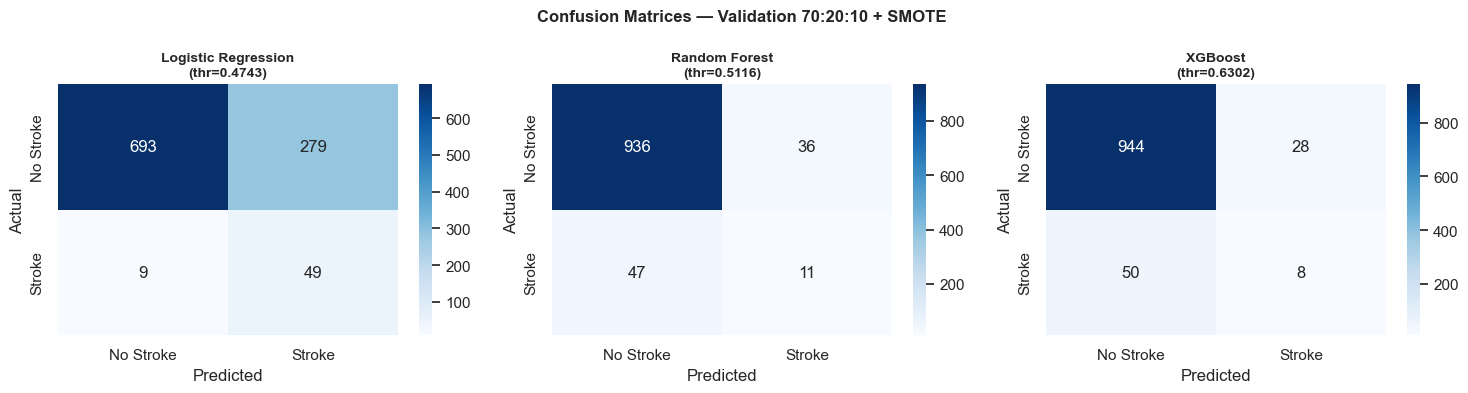

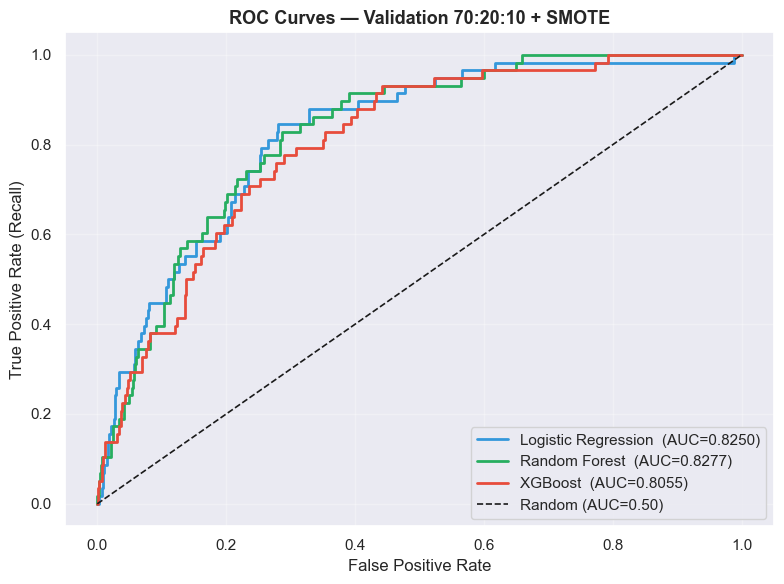

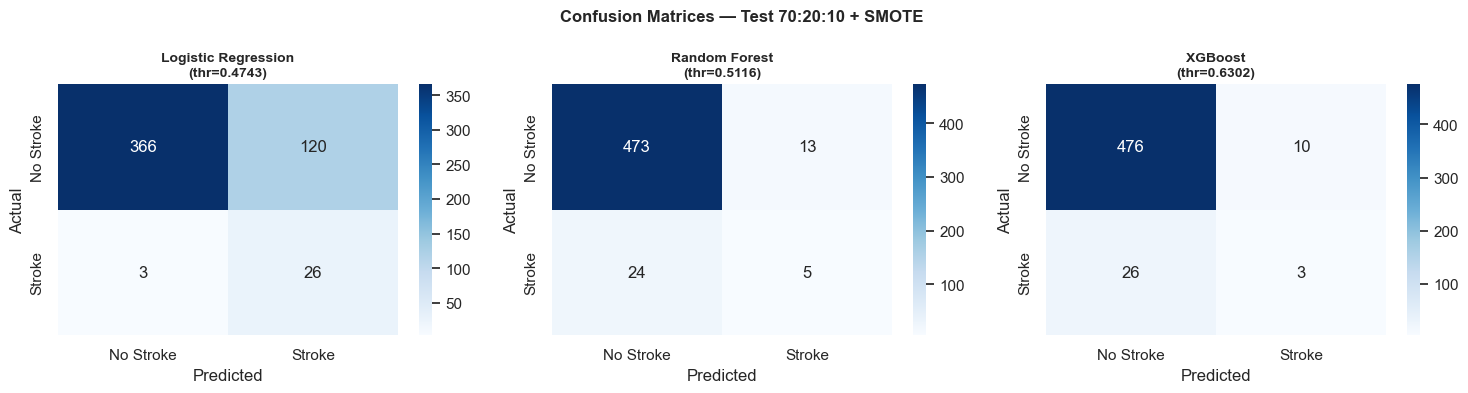

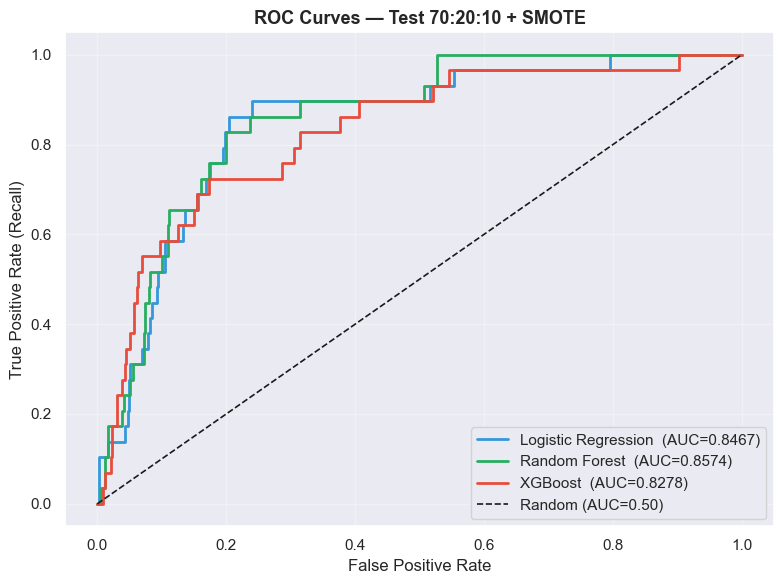

In [33]:
plot_confusion_matrices(results_val_s,
    'Confusion Matrices — Validation 70:20:10 + SMOTE',
    '04B_confusion_matrices_val_smote.png')
plot_roc_curves(results_val_s,
    'ROC Curves — Validation 70:20:10 + SMOTE',
    '04B_roc_curves_val_smote.png')
plot_confusion_matrices(results_test_s,
    'Confusion Matrices — Test 70:20:10 + SMOTE',
    '04B_confusion_matrices_test_smote.png')
plot_roc_curves(results_test_s,
    'ROC Curves — Test 70:20:10 + SMOTE',
    '04B_roc_curves_test_smote.png')

In [34]:
from sklearn.model_selection import train_test_split as tts

X_tr_i, X_te_i, y_tr_i, y_te_i = tts(X, y, test_size=0.2, random_state=42, stratify=y)
pre_i = build_preprocessor()
X_tr_i_p, _, X_te_i_p, fn = fit_and_transform(pre_i, X_tr_i, X_te=X_te_i)
neg_i, pos_i = (y_tr_i==0).sum(), (y_tr_i==1).sum()
spw_i = round(neg_i/pos_i, 2)

models_compare = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
                             LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    'Random Forest': (RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', min_samples_leaf=2, random_state=42, n_jobs=-1),
                      RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', min_samples_leaf=2, random_state=42, n_jobs=-1)),
    'XGBoost': (XGBClassifier(n_estimators=300, scale_pos_weight=spw_i, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0),
                XGBClassifier(n_estimators=300, scale_pos_weight=1.0,    max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0)),
}

smote3 = SMOTE(sampling_strategy='minority', k_neighbors=5, random_state=42)
X_tr_s_p, y_tr_s_p = smote3.fit_resample(X_tr_i_p, y_tr_i)
y_tr_s_p = pd.Series(y_tr_s_p)

comparison_rows = []
for model_name, (m_imb, m_smote) in models_compare.items():
    m_imb.fit(X_tr_i_p, y_tr_i)
    m_smote.fit(X_tr_s_p, y_tr_s_p)
    thr_i = find_youden_threshold(m_imb,   X_tr_i_p, y_tr_i)
    thr_s = find_youden_threshold(m_smote, X_tr_s_p, y_tr_s_p)

    for metric, metric_fn in [('Recall',  lambda yp, yt, t: recall_score(yt, (yp>=t).astype(int), zero_division=0)),
                               ('Precision', lambda yp, yt, t: precision_score(yt, (yp>=t).astype(int), zero_division=0)),
                               ('F1 Score',  lambda yp, yt, t: f1_score(yt, (yp>=t).astype(int), zero_division=0)),
                               ('ROC-AUC',   lambda yp, yt, t: roc_auc_score(yt, yp))]:
        yp_i = m_imb.predict_proba(X_te_i_p)[:, 1]
        yp_s = m_smote.predict_proba(X_te_i_p)[:, 1]
        v_i  = metric_fn(yp_i, y_te_i, thr_i)
        v_s  = metric_fn(yp_s, y_te_i, thr_s)
        delta = v_s - v_i
        arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
        print(f'  {model_name:<22} {metric:<14} {v_i:>12.4f} {v_s:>12.4f} {arrow}{abs(delta):>8.4f}')
        comparison_rows.append({'Model': model_name, 'Metric': metric,
                                 'Imbalanced': v_i, 'SMOTE': v_s, 'Delta': delta})
    print()

  Logistic Regression    Recall               0.8448       0.8448 =  0.0000
  Logistic Regression    Precision            0.1463       0.1526 ↑  0.0064
  Logistic Regression    F1 Score             0.2494       0.2586 ↑  0.0092
  Logistic Regression    ROC-AUC              0.8232       0.8183 ↓  0.0050

  Random Forest          Recall               0.1207       0.2069 ↑  0.0862
  Random Forest          Precision            0.5385       0.2667 ↓  0.2718
  Random Forest          F1 Score             0.1972       0.2330 ↑  0.0358
  Random Forest          ROC-AUC              0.8416       0.8165 ↓  0.0251

  XGBoost                Recall               0.4655       0.2241 ↓  0.2414
  XGBoost                Precision            0.2348       0.2281 ↓  0.0067
  XGBoost                F1 Score             0.3121       0.2261 ↓  0.0861
  XGBoost                ROC-AUC              0.8397       0.8017 ↓  0.0380



In [35]:
results_clean = [{k: v for k, v in r.items()
                  if not k.startswith('_')}
                 for r in results_80s]

results_df = pd.DataFrame(results_clean).set_index('Model')

print('\n SMOTE Model Comparison (80:20):')
print(results_df[['Accuracy','Precision','Recall',
                   'F1 Score','ROC-AUC']].round(4).to_string())


best_model_name = results_df['Recall'].idxmax()
best_recall     = results_df.loc[best_model_name, 'Recall']
best_auc        = results_df.loc[best_model_name, 'ROC-AUC']

print(f'\n Best Model : {best_model_name}')
print(f'   Recall     : {best_recall:.4f}')
print(f'   ROC-AUC    : {best_auc:.4f}')


best_model     = models_80s[best_model_name]
best_threshold = thresholds_80s[best_model_name]

print(f'   Threshold  : {best_threshold}')


 SMOTE Model Comparison (80:20):
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7272     0.1526  0.8448    0.2586   0.8183
Random Forest          0.9233     0.2667  0.2069    0.2330   0.8165
XGBoost                0.9136     0.2281  0.2241    0.2261   0.8017

 Best Model : Logistic Regression
   Recall     : 0.8448
   ROC-AUC    : 0.8183
   Threshold  : 0.4606


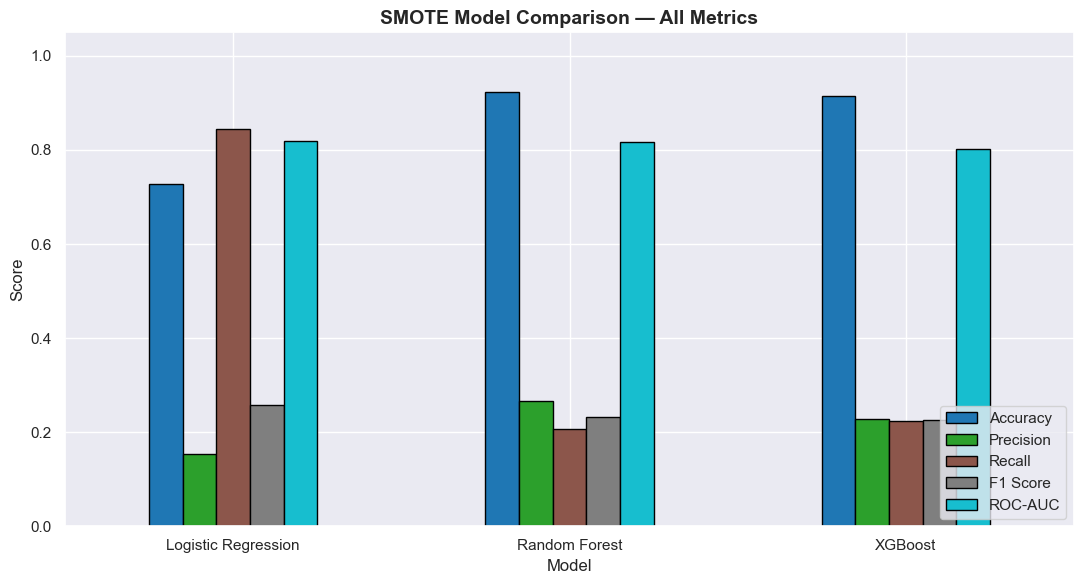

Saved: outputs/smote_model_comparison.png


In [36]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results_df[metrics_to_plot].plot(kind='bar', figsize=(11, 6),
                                 colormap='tab10', edgecolor='black')
plt.title('SMOTE Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./outputs/smote_model_comparison.png', dpi=150)
plt.show()
print('Saved: outputs/smote_model_comparison.png')

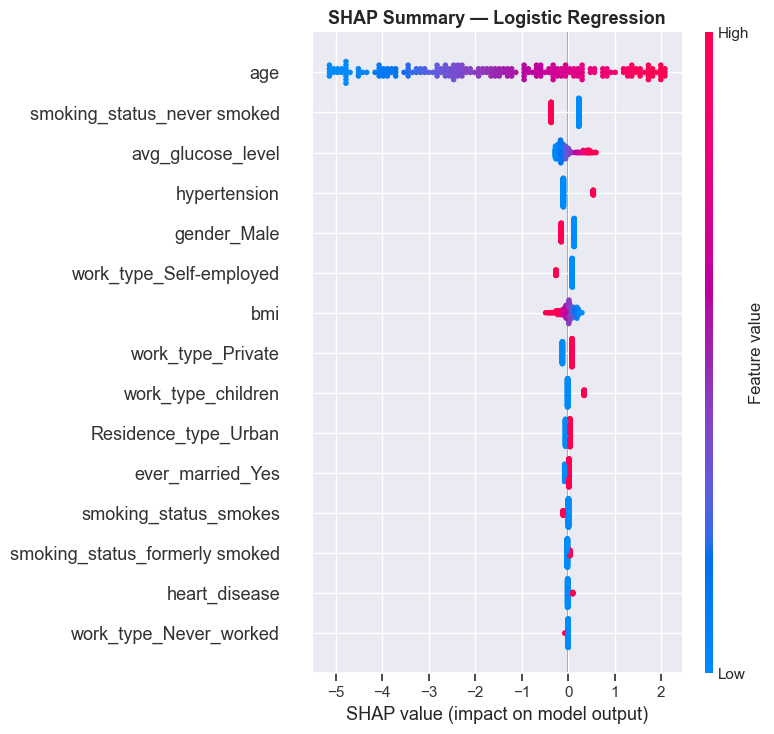

Saved: outputs/smote_shap_summary.png


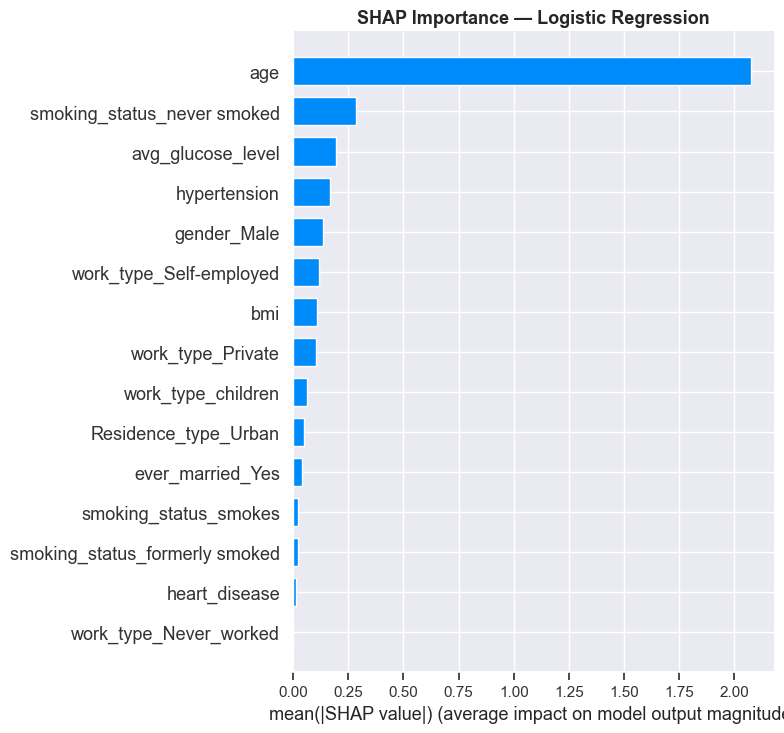

Saved: outputs/smote_shap_importance.png


In [37]:
import shap

sample_size = min(200, len(X_test_80_proc))
X_sample    = X_test_80_proc.iloc[:sample_size].reset_index(drop=True)

if best_model_name in ("Random Forest", "XGBoost"):
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    explainer   = shap.LinearExplainer(best_model, X_train_80_smote,
                                        feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_sample)
    shap_vals   = shap_values

plt.figure()
shap.summary_plot(shap_vals, X_sample, feature_names=feature_names, show=False)
plt.title(f'SHAP Summary — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/smote_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/smote_shap_summary.png')

plt.figure()
shap.summary_plot(shap_vals, X_sample, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title(f'SHAP Importance — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/smote_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/smote_shap_importance.png')

In [ ]:
import pickle, json
os.makedirs('./model', exist_ok=True)

with open('./model/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('model/best_model.pkl')


with open('./model/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor_80s, f)
print('model/preprocessor.pkl')

with open('./model/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print('model/feature_names.json')

with open('./model/best_model_name.json', 'w') as f:
    json.dump({'name': best_model_name}, f)
print('model/best_model_name.json')

with open('./model/best_threshold.json', 'w') as f:
    json.dump({'threshold': best_threshold}, f)



X_train_80_smote_df = pd.DataFrame(X_train_80_smote, columns=feature_names)
X_train_80_smote_df.to_csv('./model/X_train_sample.csv', index=False)

model/best_model.pkl
model/preprocessor.pkl
model/feature_names.json
model/best_model_name.json
model/best_threshold.json (threshold=0.4606)
model/X_train_sample.csv

 All SMOTE artefacts saved → model/ folder
